In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual theme for portfolio plots
sns.set_theme(style="whitegrid")

# Correct path using your specific repository name
data_path = '/content/drive/MyDrive/ml-ds-projects/telecom-churn-predictor/data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv'

# Read the data
df = pd.read_csv(data_path)
df.head()

Mounted at /content/drive


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# Convert TotalCharges from string object to numeric float
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check for empty spaces that turned into NaNs
missing_count = df['TotalCharges'].isnull().sum()
print(f"Missing rows in TotalCharges: {missing_count}")

# Safely drop these 11 rows since it's a tiny fraction of 7,043 rows
df.dropna(subset=['TotalCharges'], inplace=True)
print(f"Cleaned dataset shape: {df.shape}")

Missing rows in TotalCharges: 11
Cleaned dataset shape: (7032, 21)


/tmp/ipykernel_7352/2629439817.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette='Set2')


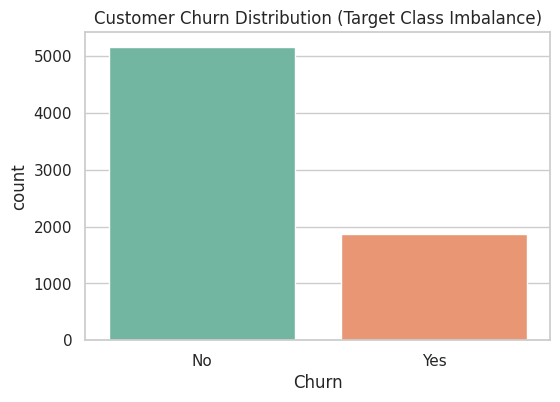

Class breakdown percentage:
Churn
No     73.42
Yes    26.58
Name: proportion, dtype: float64


In [3]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn', palette='Set2')
plt.title('Customer Churn Distribution (Target Class Imbalance)')
plt.show()

# Calculate explicit baseline percentages
print("Class breakdown percentage:")
print((df['Churn'].value_counts(normalize=True) * 100).round(2))

In [ ]:
# 1. Navigate to your root monorepo directory
%cd /content/drive/MyDrive/ml-ds-projects/

# 2. Identify yourself to Git (only needed once per session)
!git config --global user.email "valasaict582@gmail.com"
!git config --global user.name "ChanderValasai"

# 3. Stage the newly created notebook file
!git add telecom-churn-predictor/notebooks/01-eda.ipynb

# 4. Commit the changes locally
!git commit -m "Created EDA notebook, loaded raw data, and cleaned TotalCharges data type trap"

# 5. Push directly to your online GitHub repository
!git push origin main